<a href="https://colab.research.google.com/github/deboranav/analise_Machado_de_Assis/blob/exploracao/PLN_MachadoDeAssis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install nltk


In [ ]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
#Caso precise ser rodado do colab e possua o Dataset no google drive DESCOMENTE ABAIXO
# import sys
import pandas as pd
# from os import path
# from google.colab import drive
from nltk.tokenize import word_tokenize

filepath = 'obras_machado_de_assis.csv'

# # Juntar o caminho ao arquivo CSV. Conferir se colocou o caminho correto para o seu Drive

# if 'google.colab' in sys.modules:
#     drive.mount('/content/drive/', force_remount=True)
#     drive_path = 'drive/MyDrive/Disciplinas/IMD1107 - NLP/Data'
#     filepath = path.join(drive_path, filepath)

df = pd.read_csv(filepath)
df

,arquivo,caminho completo,categoria,autor,paginas,titulo,edicao,publicacao,publicacao ano,publicacao editora,publicacao cidade,edicao ano,edicao editora,edicao cidade,edicao titulo,edicao volume,texto
0,revelacoes.pdf,./pdf/crítica/revelacoes.pdf,crítica,Machado de Assis,5,"Revelações. Poesias de A. E. Zaluar, Garnier e...",Texto-Fonte: Crítica Literária de Machado de A...,Publicado originalmente no Diário do Rio de Ja...,1863,Diário do Rio de Janeiro,Rio de Janeiro,1938,W. M. Jackson,Rio de Janeiro,Crítica Literária de Machado de Assis,NaN,"Revelações. Poesias de A. E. Zaluar, Garnier e..."
1,magalhaes.pdf,./pdf/crítica/magalhaes.pdf,crítica,Machado de Assis,4,Magalhães de Azeredo: Horas sagradas; Mário de...,Texto-Fonte: Obra Completa de Machado de Assis...,"Publicado na Gazeta de Notícias, 07/12/1902.",1902,Gazeta de Notícias,Rio de Janeiro,1994,Nova Aguilar,Rio de Janeiro,Obra Completa de Machado de Assis,III,Magalhães de Azeredo: Horas sagradas; Mário de...
2,novaGeracao.pdf,./pdf/crítica/novaGeracao.pdf,crítica,Machado de Assis,22,A nova geração,Texto-Fonte: Obra Completa de Machado de Assis...,"Publicado originalmente na Revista Brasileira,...",1879,Revista Brasileira,Rio de Janeiro,1994,Nova Aguilar,Rio de Janeiro,Obra Completa de Machado de Assis,III,A nova geração\n\nI\nHá entre nós uma nova ger...
3,eduardo.pdf,./pdf/crítica/eduardo.pdf,crítica,Machado de Assis,2,Eduardo Prado,Texto-Fonte: Crítica Literária de Machado de A...,"Publicado em O Comércio de São Paulo, 1901.",1901,O Comércio de São Paulo,São Paulo,1938,W. M. Jackson,Rio de Janeiro,Crítica Literária de Machado de Assis,NaN,Eduardo Prado\n\nA última vez que vi Eduardo P...
4,cultoDever.pdf,./pdf/crítica/cultoDever.pdf,crítica,Machado de Assis,5,J.M. de Macedo: O culto do dever,Texto-Fonte: Obra Completa de Machado de Assis...,"Publicado originalmente na “Semana Literária”,...",1866,Diário do Rio de Janeiro,Rio de Janeiro,1994,Nova Aguilar,Rio de Janeiro,Obra Completa de Machado de Assis,III,J.M. de Macedo: O culto do dever\n\nO autor d'...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,contosFluminenses.pdf,./pdf/conto/contosFluminenses.pdf,conto,Machado de Assis,164,Contos Fluminenses,"Texto-fonte: Obra Completa, Machado de Assis, ...","Publicado originalmente pela Editora Garnier, ...",1870,Editora Garnier,Rio de Janeiro,1994,Nova Aguilar,Rio de Janeiro,"Obra Completa, Machado de Assis",II,Contos Fluminenses\n\nÍNDICE\nMISS DOLLAR\nLUÍ...
112,paginasRecolhidas.pdf,./pdf/conto/paginasRecolhidas.pdf,conto,Machado de Assis,43,Páginas Recolhidas,"Texto-fonte: Obra Completa, de Machado de Assi...","Publicado originalmente pela Editora Garnier, ...",1899,Editora Garnier,Rio de Janeiro,1994,Nova Aguilar,Rio de Janeiro,"Obra Completa, de Machado de Assis",II,Páginas Recolhidas\n\nÍNDICE\nPREFÁCIO\nO CASO...
113,trabalhadoresMar.pdf,./pdf/tradução/trabalhadoresMar.pdf,tradução,Machado de Assis,247,Os Trabalhadores do Mar,"Texto-fonte: Os Trabalhadores do Mar, Victor H...",Publicado originalmente como Os Trabalhadores ...,1866,Tipografia Perseverança,Rio de Janeiro,2002,Editora Nova Cultural,São Paulo,Os Trabalhadores do Mar,NaN,Os Trabalhadores do Mar\n\nÍNDICE\nDEDICATÓRIA...
114,suplicioMulher.pdf,./pdf/tradução/suplicioMulher.pdf,tradução,Machado de Assis,29,Suplício de uma mulher,"Texto-fonte: Teatro de Machado de Assis, org. ...","Publicada originalmente Obra Completa, Rio de ...",1865,W. M. Jackson,Rio de Janeiro,2003,Martins Fontes,São Paulo,Teatro de Machado de Assis,NaN,Suplício de uma mulher\n\nDRAMA EM 3 ACTOS\npo...


In [ ]:
print(df.head())
print(df.columns)  # Exibir o nome das colunas para referência


           arquivo               caminho completo categoria             autor  \
0   revelacoes.pdf   ./pdf/crítica/revelacoes.pdf   crítica  Machado de Assis   
1    magalhaes.pdf    ./pdf/crítica/magalhaes.pdf   crítica  Machado de Assis   
2  novaGeracao.pdf  ./pdf/crítica/novaGeracao.pdf   crítica  Machado de Assis   
3      eduardo.pdf      ./pdf/crítica/eduardo.pdf   crítica  Machado de Assis   
4   cultoDever.pdf   ./pdf/crítica/cultoDever.pdf   crítica  Machado de Assis   

   paginas                                             titulo  \
0        5  Revelações. Poesias de A. E. Zaluar, Garnier e...   
1        4  Magalhães de Azeredo: Horas sagradas; Mário de...   
2       22                                     A nova geração   
3        2                                      Eduardo Prado   
4        5                   J.M. de Macedo: O culto do dever   

                                              edicao  \
0  Texto-Fonte: Crítica Literária de Machado de A...   
1  Texto-F

In [ ]:
# Filtrar apenas as linhas onde a categoria é 'romance'
romances_df = df[df['categoria'] == 'romance']

# Verificar o número de textos na categoria romance
print(f"Total de textos na categoria 'romance': {len(romances_df)}")

# Exibir o título e o início do conteúdo de alguns dos textos para verificação
for index, row in romances_df[['titulo', 'texto']].head(5).iterrows():
    print(f"Título: {row['titulo']}")
    print(f"Primeiras linhas do texto: {row['texto'][:500]}")  # Exibe os primeiros 500 caracteres
    print("-" * 80)

Total de textos na categoria 'romance': 10
Título: Memórias Póstumas de Brás Cubas
Primeiras linhas do texto: Memórias Póstumas de Brás Cubas

Ao verme
que
primeiro roeu as frias carnes
do meu cadáver
dedico
como saudosa lembrança
estas
Memórias Póstumas
Prólogo da terceira edição
A primeira edição destas Memórias Póstumas de Brás Cubas foi feita
aos pedaços na Revista Brasileira, pelos anos de 1880. Postas mais
tarde em livro, corrigi o texto em vários lugares. Agora que tive de o
rever para a terceira edição, emendei ainda alguma coisa e suprimi
duas ou três dúzias de linhas. Assim composta, sai novam
--------------------------------------------------------------------------------
Título: Esaú e Jacó
Primeiras linhas do texto: Esaú e Jacó

ADVERTÊNCIA
Quando o Conselheiro Aires faleceu, acharam-se-lhe na secretária sete cadernos
manuscritos, rijamente encapados em papelão. Cada um dos primeiros seis tinha
o seu número de ordem, por algarismos romanos, I, II, III, IV, V, VI, escritos 

In [ ]:
import re
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Função para remover espaços excessivos
def remove_excessive_spaces(text: str) -> str:
    return re.sub(r'\s+', ' ', text).strip()

# Função para corrigir pontuações isoladas
def fix_isolated_commas_in_text(text: str) -> str:
    text = re.sub(r' ([.,:;!?])', r'\1', text)
    return text.strip()

# Ajustando o pipeline de limpeza
pipeline_clean_text_literario = Pipeline([
    ('remove_excessive_spaces', FunctionTransformer(remove_excessive_spaces)),
    ('fix_isolated_commas_in_text', FunctionTransformer(fix_isolated_commas_in_text)),
])

In [ ]:
# Aplicação do pipeline ajustado
romances_df = romances_df.copy()
romances_df.loc[:, 'texto_limpo'] = romances_df['texto'].apply(pipeline_clean_text_literario.transform)


In [ ]:
# Exibir o título e o início do conteúdo de alguns dos textos para verificação
for index, row in romances_df[['titulo', 'texto_limpo']].head(5).iterrows():
    print(f"Título: {row['titulo']}")
    print(f"Primeiras linhas do texto: {row['texto_limpo'][:500]}")  # Exibe os primeiros 500 caracteres
    print("-" * 80)

Título: Memórias Póstumas de Brás Cubas
Primeiras linhas do texto: Memórias Póstumas de Brás Cubas Ao verme que primeiro roeu as frias carnes do meu cadáver dedico como saudosa lembrança estas Memórias Póstumas Prólogo da terceira edição A primeira edição destas Memórias Póstumas de Brás Cubas foi feita aos pedaços na Revista Brasileira, pelos anos de 1880. Postas mais tarde em livro, corrigi o texto em vários lugares. Agora que tive de o rever para a terceira edição, emendei ainda alguma coisa e suprimi duas ou três dúzias de linhas. Assim composta, sai novame
--------------------------------------------------------------------------------
Título: Esaú e Jacó
Primeiras linhas do texto: Esaú e Jacó ADVERTÊNCIA Quando o Conselheiro Aires faleceu, acharam-se-lhe na secretária sete cadernos manuscritos, rijamente encapados em papelão. Cada um dos primeiros seis tinha o seu número de ordem, por algarismos romanos, I, II, III, IV, V, VI, escritos a tinta encarnada. O sétimo trazia este títu

#Exploração de dados

In [ ]:
romances_df['publicacao ano'] = pd.to_numeric(df['publicacao ano'], errors='coerce')  # Converte para número; 'coerce' lida com valores inválidos.


In [ ]:
ano_minimo = romances_df['publicacao ano'].min()
ano_maximo = romances_df['publicacao ano'].max()

print(ano_minimo)


1872


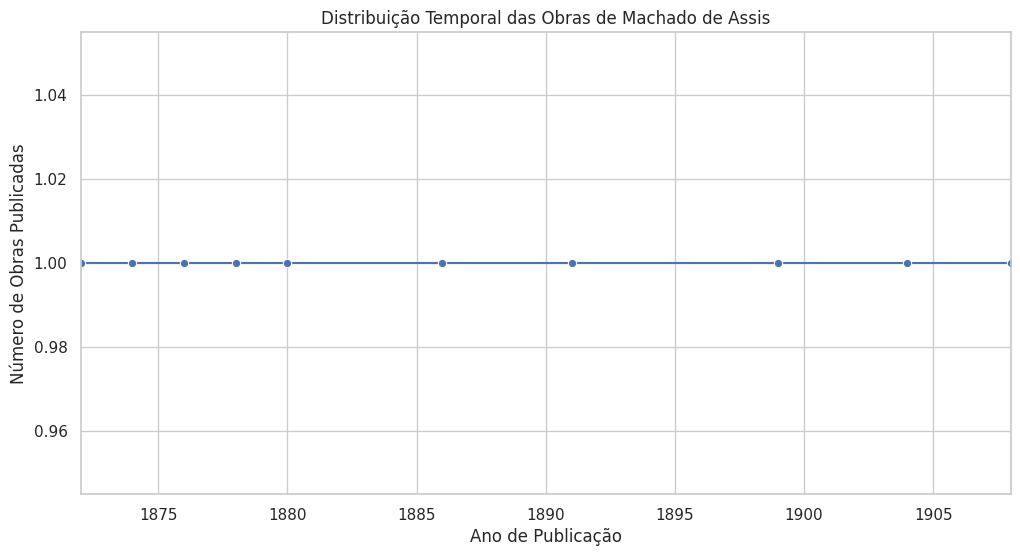

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de estilo
sns.set(style="whitegrid")

# Contar quantas obras foram publicadas por ano
publicacoes_por_ano = romances_df['publicacao ano'].value_counts().sort_index()

# Criar o gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(x=publicacoes_por_ano.index, y=publicacoes_por_ano.values, marker="o")

# Ajuste dos limites do eixo x para o intervalo relevante
plt.xlim(ano_minimo, ano_maximo)

# Títulos e rótulos
plt.title("Distribuição Temporal das Obras de Machado de Assis")
plt.xlabel("Ano de Publicação")
plt.ylabel("Número de Obras Publicadas")
plt.show()



In [ ]:
romances_df['tokens'] = romances_df['texto'].apply(word_tokenize)

In [ ]:
print(romances_df[['texto', 'tokens']])

                                                texto  \
55  Memórias Póstumas de Brás Cubas\n\nAo verme\nq...   
56  Esaú e Jacó\n\nADVERTÊNCIA\nQuando o Conselhei...   
57  Helena\n\nADVERTÊNCIA\nEsta nova edição de Hel...   
58  Ressurreição\n\nADVERTÊNCIA DA NOVA EDIÇÃO\nEs...   
59  A Mão e a Luva\n\nAdvertência de 1907\nOs trin...   
60  Memorial de Aires\n\nEm Lixboa, sobre lo mar,\...   
61  Casa Velha\n\nCAPÍTULO PRIMEIRO\nANTES E DEPOI...   
62  Quincas Borba\n\nPRÓLOGO DA 3ª EDIÇÃO\nA segun...   
63  Dom Casmurro\n\nCAPÍTULO PRIMEIRO\nDO TÍTULO\n...   
64  Iaiá Garcia\n\nCAPÍTULO PRIMEIRO\nLuís Garcia ...   

                                               tokens  
55  [Memórias, Póstumas, de, Brás, Cubas, Ao, verm...  
56  [Esaú, e, Jacó, ADVERTÊNCIA, Quando, o, Consel...  
57  [Helena, ADVERTÊNCIA, Esta, nova, edição, de, ...  
58  [Ressurreição, ADVERTÊNCIA, DA, NOVA, EDIÇÃO, ...  
59  [A, Mão, e, a, Luva, Advertência, de, 1907, Os...  
60  [Memorial, de, Aires, Em, Lixboa

In [ ]:
# Criar uma nova coluna com a contagem de palavras de cada obra
romances_df['contagem_palavras'] = romances_df['texto'].apply(lambda x: len(x.split()))


In [ ]:
# Visualizar as primeiras linhas do DataFrame com a nova coluna
romances_df[['titulo', 'contagem_palavras']].head(10)


,titulo,contagem_palavras
55,Memórias Póstumas de Brás Cubas,61290
56,Esaú e Jacó,72252
57,Helena,56247
58,Ressurreição,36909
59,A Mão e a Luva,35301
60,Memorial de Aires,50865
61,Casa Velha,22227
62,Quincas Borba,77322
63,Dom Casmurro,66174
64,Iaiá Garcia,56637


In [ ]:
romances_df_ordenado = romances_df.sort_values(by="publicacao ano", ascending=True)

In [ ]:
romances_df_ordenado[['titulo', 'contagem_palavras', 'publicacao ano']].head(10)

,titulo,contagem_palavras,publicacao ano
58,Ressurreição,36909,1872
59,A Mão e a Luva,35301,1874
57,Helena,56247,1876
64,Iaiá Garcia,56637,1878
55,Memórias Póstumas de Brás Cubas,61290,1880
61,Casa Velha,22227,1886
62,Quincas Borba,77322,1891
63,Dom Casmurro,66174,1899
56,Esaú e Jacó,72252,1904
60,Memorial de Aires,50865,1908


##Nuvens de palavras

In [ ]:
# Concatenar todos os textos em uma única string
texto_completo = " ".join(romances_df['texto'].tolist())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


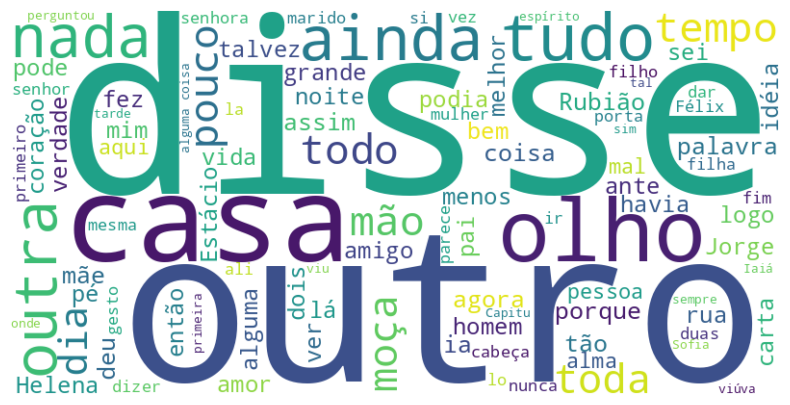

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

# Certifique-se de ter baixado as stopwords do nltk
nltk.download("stopwords")

# Carregar stopwords em português
stop_words = set(stopwords.words('portuguese'))

# Criar a nuvem de palavras sem stopwords
wordcloud = WordCloud(width=800, height=400, background_color="white",
                      stopwords=stop_words, max_words=100, colormap="viridis").generate(texto_completo)

# Mostrar a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


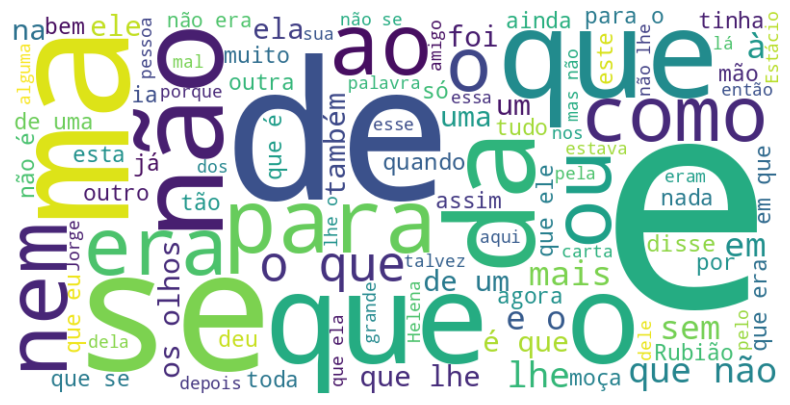

In [ ]:
# Criar a nuvem de palavras incluindo stopwords
wordcloud_com_stopwords = WordCloud(width=800, height=400, background_color="white",
                                    max_words=100, colormap="viridis").generate(texto_completo)

# Mostrar a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_com_stopwords, interpolation="bilinear")
plt.axis("off")
plt.show()


In [ ]:
# Filtrar o DataFrame para o intervalo de 1872 a 1880
df_periodo1 = romances_df[(romances_df['publicacao ano'] >= 1872) & (romances_df['publicacao ano'] <= 1880)]
# Concatenar todos os textos do período em uma única string
texto_periodo1 = " ".join(df_periodo1['texto'].tolist())


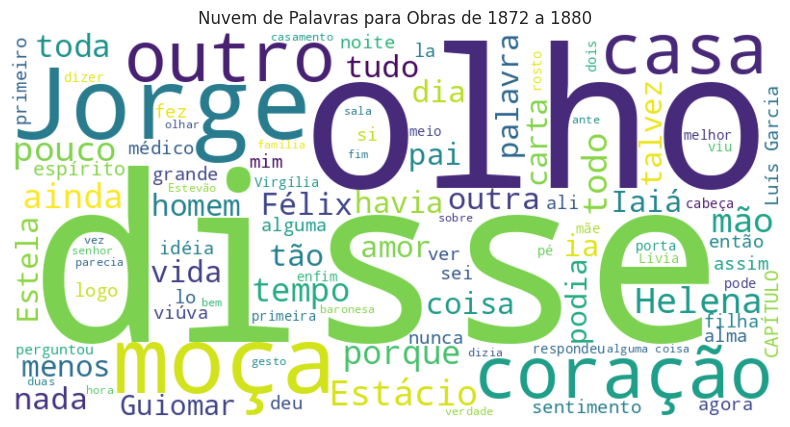

In [ ]:
# Criar a nuvem de palavras para o período de 1872 a 1880
wordcloud_periodo1 = WordCloud(width=800, height=400, background_color="white",
                              stopwords=stop_words, max_words=100, colormap="viridis").generate(texto_periodo1)

# Mostrar a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_periodo1, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras para Obras de 1872 a 1880")
plt.show()

In [ ]:
# Filtrar o DataFrame para o intervalo de 1872 a 1880
df_periodo2 = romances_df[(romances_df['publicacao ano'] >= 1885) & (romances_df['publicacao ano'] <= 1907)]
# Concatenar todos os textos do período em uma única string
texto_periodo2 = " ".join(df_periodo2['texto'].tolist())


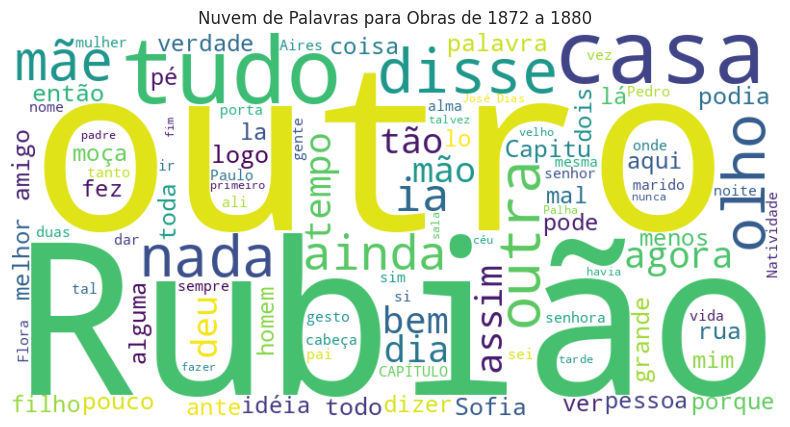

In [ ]:
# Criar a nuvem de palavras para o período de 1872 a 1880
wordcloud_periodo2 = WordCloud(width=800, height=400, background_color="white",
                              stopwords=stop_words, max_words=100, colormap="viridis").generate(texto_periodo2)

# Mostrar a nuvem de palavras
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_periodo2, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de Palavras para Obras de 1872 a 1880")
plt.show()

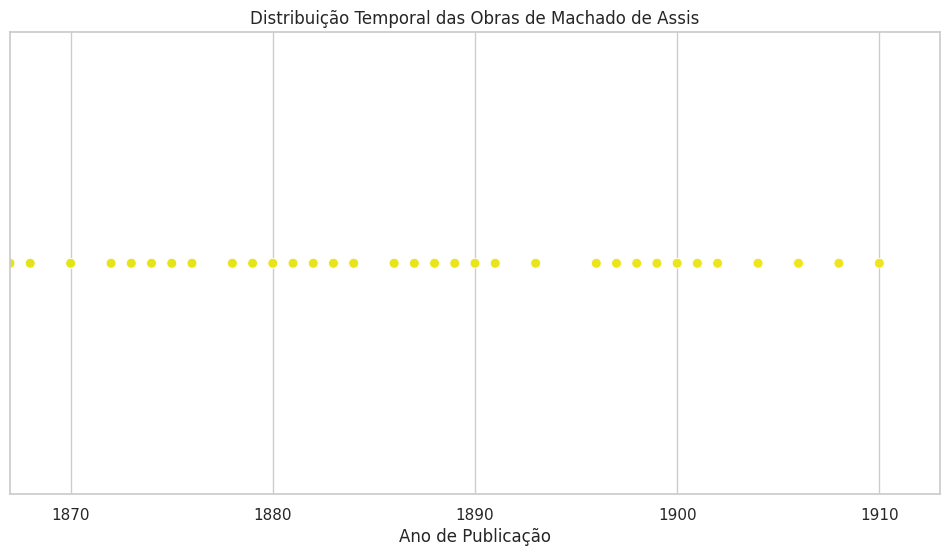

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de estilo
sns.set(style="whitegrid")

# Criar o gráfico de dispersão
plt.figure(figsize=(12, 6))
sns.scatterplot(x='publicacao ano', y=[1] * len(df), data=df, hue='publicacao ano', palette='viridis', legend=None, s=50)

# Ajuste dos limites do eixo x
plt.xlim(romances_df['publicacao ano'].min() - 5, romances_df['publicacao ano'].max() + 5)  # Adiciona uma margem

# Títulos e rótulos
plt.title("Distribuição Temporal das Obras de Machado de Assis")
plt.xlabel("Ano de Publicação")
plt.yticks([])  # Remove o eixo y, pois não é necessário
plt.ylabel("")
plt.show()


In [ ]:
import pandas as pd
import nltk
import numpy as np

# Certifique-se de ter os dados carregados no DataFrame df, com uma coluna "texto" e outra "Ano"
# Exemplo:
# df = pd.read_csv("obras_machado.csv")

# Função para contar palavras
def contar_palavras(texto):
    palavras = nltk.word_tokenize(texto)  # Tokeniza o texto em palavras
    return len(palavras)

# Função para contar frases
def contar_frases(texto):
    frases = nltk.sent_tokenize(texto)  # Tokeniza o texto em frases
    return len(frases)

# Adicionar as colunas de contagem de palavras e frases ao DataFrame
df['num_palavras'] = df['texto'].apply(contar_palavras)
df['num_frases'] = df['texto'].apply(contar_frases)

# Calcular o comprimento médio em palavras e frases por obra
df['comprimento_medio_palavras'] = df['num_palavras'] / df['num_frases']

# Exibir o DataFrame para verificar os resultados
print(df[['Ano', 'num_palavras', 'num_frases', 'comprimento_medio_palavras']])

# Opcional: Visualizar a média do comprimento das obras ao longo dos anos
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Calcular a média de palavras por ano
comprimento_medio_por_ano = df.groupby('Ano')['comprimento_medio_palavras'].mean()

# Plotar o gráfico
plt.plot(comprimento_medio_por_ano.index, comprimento_medio_por_ano.values, marker='o', linestyle='-')
plt.title("Comprimento Médio das Obras de Machado de Assis ao Longo dos Anos")
plt.xlabel("Ano de Publicação")
plt.ylabel("Comprimento Médio (Palavras por Frase)")
plt.grid(True)
plt.show()


LookupError: 
**********************************************************************
  Resource [93mpunkt[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt/PY3/english.pickle[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
    - ''
**********************************************************************
